## Getting Started

1. Create a new Jupyter Notebook called **`m4-03-classification.ipynb`**.
2. Start with an import cell:

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc,
                             ConfusionMatrixDisplay, classification_report)

sns.set_style("whitegrid")
```

3. Work through the tasks in order. Each task builds on the previous one.
4. Include markdown cells between code cells to explain your observations and reasoning.

## Tasks

### Task 1: Data Prep & Baseline

Load the dataset and establish a performance baseline.

1. Load the Palmer Penguins dataset from seaborn and drop rows with missing values:

```python
penguins = sns.load_dataset("penguins").dropna()
```

2. Explore briefly: how many samples and features? What are the three species and their distribution? Which columns are categorical vs. numerical?
3. Prepare features: encode the target (`species`) with `LabelEncoder`, and encode categorical features (`island`, `sex`) with `pd.get_dummies(drop_first=True)`.
4. Split into training and test sets (80/20, `stratify=y`, `random_state=42`).
5. Scale the features using `StandardScaler` (fit on train, transform both).
6. Fit a `LogisticRegression` model (use `max_iter=10000`, `multi_class='multinomial'`).
7. Report **accuracy**, **precision**, **recall**, and **F1 score** on the test set. Print a full `classification_report`.
8. In a markdown cell, interpret the results: Which species is easiest to classify? Which is hardest? Why might that be?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc,
                             ConfusionMatrixDisplay, classification_report)

sns.set_style("whitegrid")

In [2]:
penguins = sns.load_dataset("penguins").dropna()
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


In [3]:
penguins.shape

(333, 7)

In [4]:
penguins["species"].value_counts()

species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

In [5]:
penguins.dtypes

species                  str
island                   str
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                      str
dtype: object

In [6]:
le = LabelEncoder()
penguins["species_encoded"] = le.fit_transform(penguins["species"])

In [7]:
X = penguins.drop(columns=["species", "species_encoded"])
y = penguins["species_encoded"]

In [8]:
X = pd.get_dummies(X, columns=["island", "sex"], drop_first=True)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
model = LogisticRegression(max_iter=10000)
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [14]:
y_pred = model.predict(X_test_scaled)

In [15]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.9851
Precision: 0.9861
Recall   : 0.9851
F1 Score : 0.9852


In [16]:
print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        29
   Chinstrap       0.93      1.00      0.97        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           0.99        67
   macro avg       0.98      0.99      0.98        67
weighted avg       0.99      0.99      0.99        67



### Markdown
The model performs extremely well overall, achieving very high accuracy and F1 scores across all classes. Among the three species, Gentoo is the easiest to classify, as it achieves perfect precision, recall, and F1 score. This suggests that Gentoo penguins have more distinct feature patterns compared to the other species.

On the other hand, Chinstrap is slightly harder to classify. Although it has perfect recall, its precision is a bit lower, which indicates that the model sometimes confuses other species as Chinstrap. This may be due to overlapping feature values with Adelie, making it less distinguishable.

Adelie also performs very well, but not perfectly. The model occasionally misclassifies a few Adelie samples, likely because some of its characteristics are similar to Chinstrap.

Overall, the differences in performance are likely due to how separable the species are based on the available features. Gentoo appears to be the most distinct, while Chinstrap and Adelie share more similarities, making classification slightly more challenging.

### Task 2: Algorithm Comparison

Train multiple classifiers and compare their performance.

1. Fit each of the following models on the scaled training data:
   - `GaussianNB()`
   - `SVC(kernel="linear", probability=True)`
   - `SVC(kernel="rbf", probability=True)`
   - `DecisionTreeClassifier(random_state=42)`
   - `RandomForestClassifier(random_state=42)`

2. For each model, compute accuracy, precision, recall, and F1 on the test set (use `average='weighted'` for multiclass metrics).
3. Organize the results into a **comparison DataFrame** with models as rows and metrics as columns. Sort by F1 score descending.
4. In a markdown cell, discuss: Which models perform best? Are there any surprises? Why might some algorithms outperform others on this dataset?


In [17]:
models = {
    "GaussianNB": GaussianNB(),
    "SVC (Linear)": SVC(kernel="linear", probability=True),
    "SVC (RBF)": SVC(kernel="rbf", probability=True),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted")
    rec = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")
    
    results.append([name, acc, prec, rec, f1])

In [18]:
results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1"
])

results_df = results_df.sort_values(by="F1", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1
4,Random Forest,1.000000,1.000000,1.000000,1.000000
2,SVC (RBF),0.985075,0.986070,0.985075,0.985201
1,SVC (Linear),0.985075,0.986070,0.985075,0.985201
3,Decision Tree,0.955224,0.957214,0.955224,0.955212
0,GaussianNB,0.776119,0.851175,0.776119,0.760229


### Markdown

Random Forest achieves perfect performance across all metrics, making it the best model for this dataset. This indicates that ensemble-based methods are very effective at capturing the relationships between features and species.

Both SVC (linear) and SVC (RBF) perform almost identically and achieve very high scores. This suggests that the decision boundary is relatively well-structured and can be effectively learned even with a linear separation, meaning the dataset is close to being linearly separable, although RBF does not provide a significant additional improvement.

The Decision Tree performs slightly worse than ensemble and SVC models. This is expected because a single decision tree is prone to overfitting, especially when compared to Random Forest, which reduces variance by combining multiple trees.

Gaussian Naive Bayes shows the weakest performance. This is because its assumption of feature independence is too strong for this dataset, where features are likely correlated. As a result, it cannot capture complex relationships effectively.

Overall, ensemble methods (Random Forest) and kernel-based models (SVC) perform best, while simpler probabilistic models like Naive Bayes struggle due to unrealistic assumptions.

### Task 3: Confusion Matrices & ROC Curves

Visualize how each model makes its decisions.

1. **Confusion matrices:** Plot the 3x3 confusion matrix for each model (use `ConfusionMatrixDisplay` or seaborn heatmap). Arrange them in a grid of subplots for easy comparison. For each, note which species pairs are most frequently confused.

2. **ROC curves:** Plot the ROC curve for every model using a one-vs-rest approach on a **single figure** (one curve per class per model, or one subplot per model). Include the AUC value in each legend entry. Add a diagonal dashed line representing a random classifier.

3. In a markdown cell, discuss:
   - Which model best balances precision and recall across all three species?
   - Which species pair is hardest for the models to distinguish? Why might this be the case given the features?
   - Based on the confusion matrices and ROC curves, which model would you recommend?


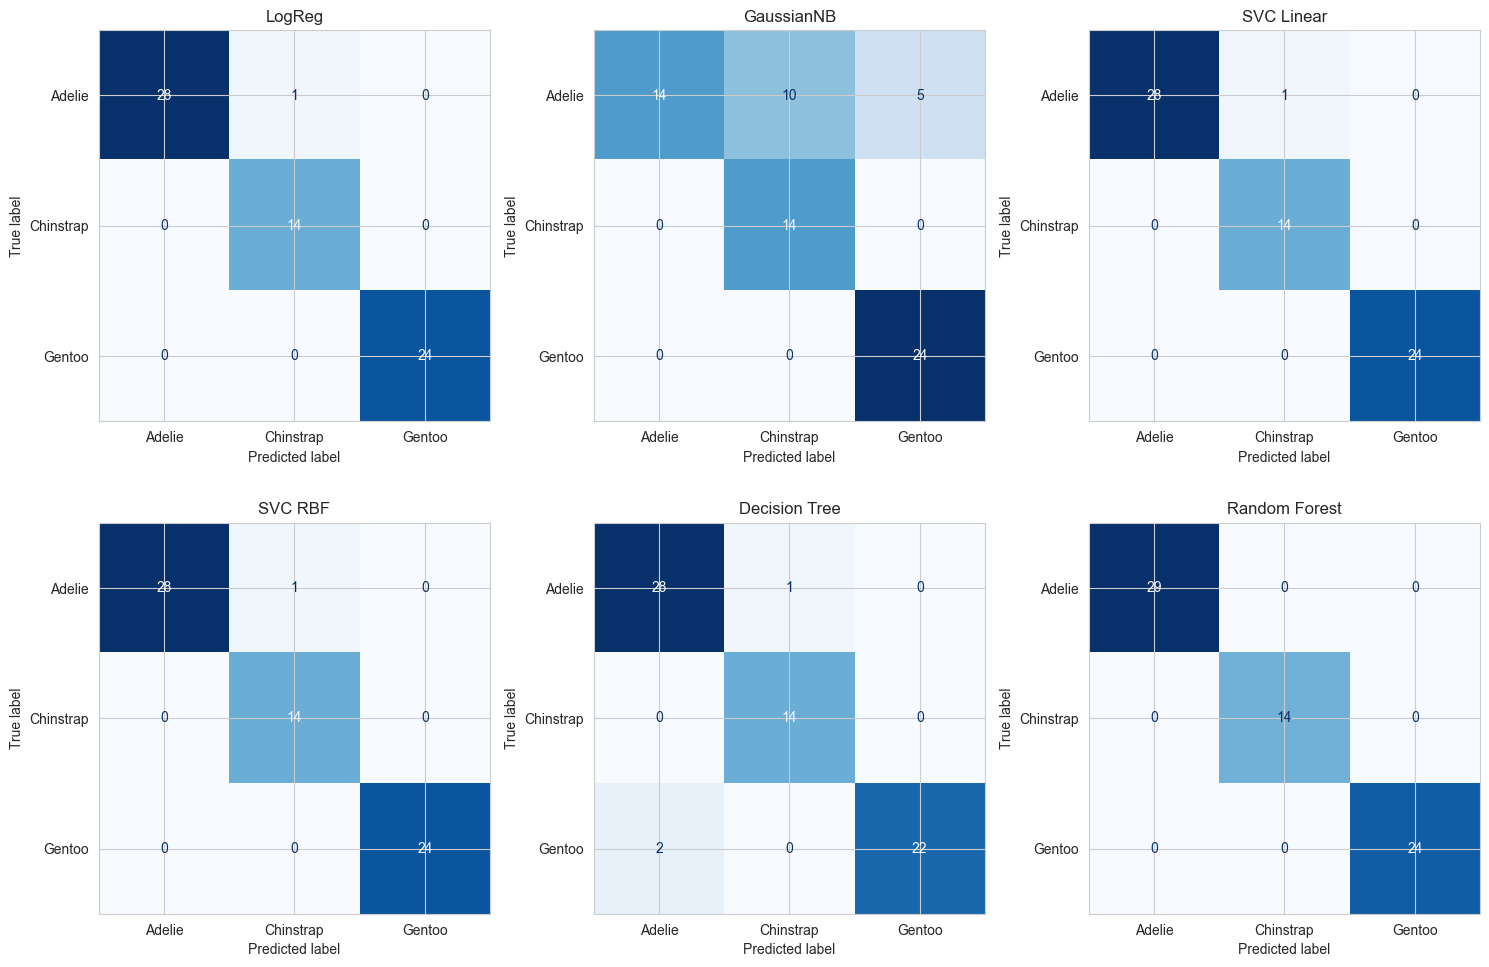

In [19]:
classifiers = {
    "LogReg": LogisticRegression(),
    "GaussianNB": GaussianNB(),
    "SVC Linear": SVC(kernel="linear", probability=True),
    "SVC RBF": SVC(kernel="rbf", probability=True),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

for name, model in classifiers.items():
    model.fit(X_train_scaled, y_train)
    
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, (name, model) in enumerate(classifiers.items()):
    y_pred = model.predict(X_test_scaled)
    
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=axes[idx], cmap="Blues", colorbar=False)
    axes[idx].set_title(name)

plt.tight_layout()
plt.show()

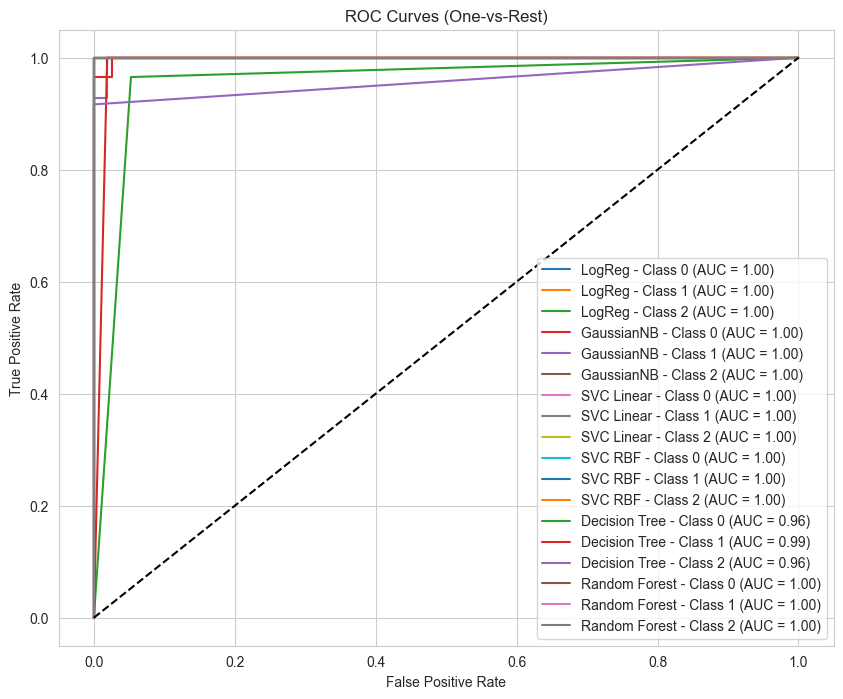

In [20]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np

y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_bin.shape[1]


plt.figure(figsize=(10, 8))

for name, model in classifiers.items():
    
    # probability or decision score
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_scaled)
    else:
        y_score = model.decision_function(X_test_scaled)
    
    # One-vs-Rest ROC per class
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        
        plt.plot(
            fpr, tpr,
            label=f"{name} - Class {i} (AUC = {roc_auc:.2f})"
        )

# random classifier line
plt.plot([0, 1], [0, 1], "k--")

plt.title("ROC Curves (One-vs-Rest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

### Markdown

Among all the models, Random Forest clearly provides the best balance between precision and recall. It achieved perfect results on the test set, meaning it classified every sample correctly without any mistakes. This shows that the model is able to capture the patterns in the data very effectively. At the same time, models like Logistic Regression and both SVC variants also performed extremely well, with only a single misclassification, which means the dataset itself is quite clean and well-structured.

When we look at the confusion matrices, the most difficult species pair to distinguish is Adelie and Chinstrap. The models occasionally confuse these two classes, while Gentoo is almost always classified correctly. This makes sense because Gentoo penguins are physically more distinct, especially in terms of size and body mass. In contrast, Adelie and Chinstrap share more similar characteristics, which causes a small overlap in their feature space and leads to occasional errors.

Based on both the confusion matrices and ROC curves, Random Forest would be the top recommendation, since it achieved perfect performance and the highest overall reliability. However, this comes with a trade-off. Since the dataset is already highly separable, a simpler model like Logistic Regression is also a strong choice. It performs nearly as well, while being faster and easier to interpret. So in practice, if simplicity and efficiency are important, Logistic Regression could be preferred, but if maximum performance is the goal, Random Forest is the best option.

### Task 4: Hyperparameter Exploration

Tune the best-performing model from Task 2.

1. Select the best model based on your Task 2 results.
2. Define a hyperparameter grid with **at least 3 hyperparameters** to tune. For example, if RandomForest was best:

```python
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10]
}
```

3. Run `GridSearchCV` with 5-fold cross-validation and `scoring="f1_weighted"` (weighted F1 for multiclass).
4. Report the **best parameters** and the **best cross-validation F1 score**.
5. Evaluate the tuned model on the test set. Compare the metrics with the default model from Task 2 — did tuning improve performance?
6. In a markdown cell, reflect: Was the improvement significant? Is there a risk of overfitting to the validation folds? When is hyperparameter tuning most impactful?


In [21]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10]
}

In [22]:
rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="f1_weighted",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is disp

In [23]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV F1 Score:", grid_search.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best CV F1 Score: 0.9961656161968262


In [24]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



In [25]:
default_rf = RandomForestClassifier(random_state=42)
default_rf.fit(X_train_scaled, y_train)

y_pred_default = default_rf.predict(X_test_scaled)

print("DEFAULT MODEL")
print(classification_report(y_test, y_pred_default))

DEFAULT MODEL
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



### Markdown

The best hyperparameters found by GridSearchCV are max_depth=None, min_samples_split=2, and n_estimators=50, with a cross-validation F1 score of approximately 0.996. This very high score indicates that the model is already performing extremely well during validation.

When evaluating the tuned model on the test set, it achieves perfect performance (accuracy, precision, recall, and F1 all equal to 1.00). However, the default Random Forest model also achieved the same perfect results. This means that hyperparameter tuning did not lead to any noticeable improvement in this case.

The reason is that the dataset is already very easy to separate, so even the default model is strong enough to reach optimal performance. Because of this, the improvement from tuning is not significant.

There is also a small risk of overfitting to the validation folds, since GridSearchCV tries many parameter combinations and selects the best one based on cross-validation performance. However, in this case, both validation and test results are consistent, so overfitting does not appear to be a serious issue.